In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pickle
import glob
import os
from pandas.api.types import CategoricalDtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


In [2]:
df=pd.read_parquet('F_dataset.parquet')

In [3]:
df.head()

,usr,nnumr,cnumr,elpl,jobenv_req,pri,mszl,freq_req,duration
0,usr_724,1,48,120.0,jobenv_req_0,127,1.844674e+19,2000,24.183333
1,usr_724,1,48,120.0,jobenv_req_0,127,1.844674e+19,2000,22.666667
2,usr_724,1,48,120.0,jobenv_req_0,127,1.844674e+19,2000,23.466667
3,usr_724,1,48,120.0,jobenv_req_0,127,1.844674e+19,2000,24.066667
4,usr_724,1,48,120.0,jobenv_req_0,127,1.844674e+19,2000,23.533333


In [4]:
Xt=df[["usr", "nnumr", "cnumr", "elpl", "jobenv_req", "pri", "mszl", "freq_req"]]
Yt=df["duration"]

In [5]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(categorical_columns)

['usr', 'jobenv_req']


In [6]:
numerical_cols = ["nnumr", "cnumr", "elpl", "pri", "mszl", "freq_req"]  
categorical_cols = ["usr", "jobenv_req"]  


encoder = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
scaler = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
    ('num', scaler, numerical_cols),
    ('cat', encoder, categorical_cols)
],sparse_threshold=1.0)

Xt_processed = preprocessor.fit_transform(Xt)
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + cat_feature_names.tolist()
Xt_processed_df = pd.DataFrame(
    Xt_processed.toarray(),   
    columns=all_feature_names
)

In [7]:
num_df = Xt_processed_df[numerical_cols]

means = num_df.mean()
vars_  = num_df.var(ddof=0)  

print("Means:\n", means)
print("Variances:\n", vars_)

Means:
 nnumr       1.102775e-13
cnumr       1.102632e-13
elpl        1.365115e-13
pri        -4.887820e-14
mszl       -2.836412e-12
freq_req   -6.992999e-12
dtype: float64
Variances:
 nnumr       1.0
cnumr       1.0
elpl        1.0
pri         1.0
mszl        1.0
freq_req    1.0
dtype: float64


In [8]:
Yt.to_frame(name="duration").to_parquet("Yt.parquet", index=False)

In [9]:
import pyarrow as pa, pyarrow.parquet as pq

In [10]:
df = Xt_processed_df
chunk = 50_000  

schema = pa.Table.from_pandas(df.iloc[:0], preserve_index=False).schema
with pq.ParquetWriter("Xt.parquet", schema,
                      compression="snappy",      
                      use_dictionary=False,
                      write_statistics=False) as w:
    for i in range(0, len(df), chunk):
        part = pa.Table.from_pandas(df.iloc[i:i+chunk], preserve_index=False)
        w.write_table(part)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(Xt_processed_df, Yt, test_size=0.1, shuffle= True, random_state=42)

In [26]:
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
long_indices = y_test > 1

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAPE:", mean_absolute_percentage_error(y_test[long_indices], y_pred_rf[long_indices]))


Random Forest Results
MAE: 80.42213360325466
MSE: 49403.44893029044
RMSE: 222.26886630900523
MAPE: 4.390019272483162


In [9]:
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

In [28]:
gb = GradientBoostingRegressor(
    n_estimators=50,    
    learning_rate=0.2,   
    max_depth=7,        
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
long_indices = y_test > 1


print("Gradient Boost Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("MSE:", mean_squared_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("MAPE:", mean_absolute_percentage_error(y_test[long_indices], y_pred_gb[long_indices]))

Gradient Boost Results:
MAE: 78.7671348434508
MSE: 43246.30241013434
RMSE: 207.957453365188
MAPE: 4.941041704405158


In [10]:
import torch
import torch.nn as nn
import copy
import torch.optim as optim
import tqdm
import optuna
from sklearn.model_selection import train_test_split
print(torch.__version__)

2.2.2


In [11]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [12]:
def pandas_sparse_to_torch(df_sparse):
    coo = df_sparse.sparse.to_coo()  
    indices = torch.vstack((
        torch.from_numpy(coo.row).long(),
        torch.from_numpy(coo.col).long()
    ))
    values = torch.from_numpy(coo.data).float()
    return torch.sparse_coo_tensor(indices, values, size=coo.shape).coalesce()

X_train_tensor = pandas_sparse_to_torch(X_train)   
X_test_tensor  = pandas_sparse_to_torch(X_test)

y_train_tensor = torch.tensor(np.asarray(y_train, dtype=np.float32)).reshape(-1, 1)
y_test_tensor  = torch.tensor(np.asarray(y_test,  dtype=np.float32)).reshape(-1, 1)


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Xtr_csr = X_train.sparse.to_coo().tocsr()
Xte_csr = X_test.sparse.to_coo().tocsr()

y_train_np = y_train.to_numpy(dtype="float32").reshape(-1, 1)
y_test_np  = y_test.to_numpy(dtype="float32").reshape(-1, 1)

def get_dense_batch_from_csr(csr_mat, rows):
    return csr_mat[rows].toarray().astype("float32")

In [ ]:
def objective(trial):
    hidden1 = trial.suggest_int("hidden1", 64, 256)
    hidden2 = trial.suggest_int("hidden2", 32, 128)
    hidden3 = trial.suggest_int("hidden3", 16, 64)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    n_epochs = trial.suggest_int("n_epochs", 50, 200)

    in_dim = Xtr_csr.shape[1]  
    model = nn.Sequential(
        nn.Linear(in_dim, hidden1),
        nn.ReLU(),
        nn.Linear(hidden1, hidden2),
        nn.ReLU(),
        nn.Linear(hidden2, hidden3),
        nn.ReLU(),
        nn.Linear(hidden3, 1)
    ).to(device)

    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    n_train = Xtr_csr.shape[0]
    best_mse = np.inf
    best_weights = None

    for epoch in range(n_epochs):
        model.train()
        idx = np.random.permutation(n_train)
        for start in range(0, n_train, batch_size):
            rows = idx[start:start+batch_size]
            X_batch = get_dense_batch_from_csr(Xtr_csr, rows)
            y_batch = y_train_np[rows]

            X_batch = torch.from_numpy(X_batch).to(device)
            y_batch = torch.from_numpy(y_batch).to(device)

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            X_test_dense = torch.from_numpy(Xte_csr.toarray().astype("float32")).to(device)
            y_test_dense = torch.from_numpy(y_test_np).to(device)
            y_pred = model(X_test_dense)
            mse = loss_fn(y_pred, y_test_dense).item()
            if mse < best_mse:
                best_mse = mse
                best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    model.eval()
    with torch.no_grad():
        X_test_dense = torch.from_numpy(Xte_csr.toarray().astype("float32")).to(device)
        y_test_dense = torch.from_numpy(y_test_np).to(device)
        y_pred = model(X_test_dense).cpu().numpy()
        y_true = y_test_dense.cpu().numpy()
        mape = mean_absolute_percentage_error(y_true, y_pred)

    return mape


In [16]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30, timeout=600)

[I 2025-08-15 17:30:37,208] A new study created in memory with name: no-name-e7f9ef60-3aa6-4fc0-badc-87cf0a953125
[W 2025-08-15 17:53:33,141] Trial 0 failed with parameters: {'hidden1': 195, 'hidden2': 126, 'hidden3': 46, 'lr': 0.002391154359324237, 'batch_size': 64, 'n_epochs': 55} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/basak/miniforge3/lib/python3.12/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/lj/88mth58x7277_6kldjrctjvw0000gn/T/ipykernel_20615/4172532967.py", line 38, in objective
    y_pred = model(X_batch)
             ^^^^^^^^^^^^^^
  File "/Users/basak/miniforge3/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1511, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/basak/miniforge3/lib/python3.12/site-packages/torch/nn

KeyboardInterrupt: 

In [3]:
df=pd.read_parquet('21_04.parquet')

In [4]:
print(df.columns)

Index(['jid', 'usr', 'jnam', 'cnumr', 'cnumat', 'cnumut', 'nnumr', 'adt',
       'qdt', 'schedsdt', 'deldt', 'ec', 'elpl', 'sdt', 'edt', 'nnuma',
       'idle_time_ave', 'nnumu', 'perf1', 'perf2', 'perf3', 'perf4', 'perf5',
       'perf6', 'mszl', 'pri', 'econ', 'avgpcon', 'minpcon', 'maxpcon', 'msza',
       'mmszu', 'uctmut', 'sctmut', 'usctmut', 'jobenv_req', 'freq_req',
       'freq_alloc', 'flops', 'mbwidth', 'opint', 'pclass', 'embedding',
       'exit state', 'duration'],
      dtype='object')


In [5]:
df['duration'] = df['duration'] / 60

In [9]:
short_jobs = df[df["duration"] < 1].shape[0]
total_jobs = df.shape[0]
ratio=short_jobs / total_jobs
print(ratio)

0.2953743043504279


In [6]:
Ys = df["duration"]
Xs = df[["usr", "nnumr", "cnumr", "elpl", "jobenv_req", "pri"]]

In [7]:
numerical_cols = ["nnumr", "cnumr"]  
categorical_cols = ["usr", "elpl", "jobenv_req", "pri"]  

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
    ('num', scaler, numerical_cols),
    ('cat', encoder, categorical_cols)
])

Xs_processed = preprocessor.fit_transform(Xs)
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + cat_feature_names.tolist()
Xs_processed_df = pd.DataFrame(Xs_processed, columns=all_feature_names)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(Xs_processed_df, Ys, test_size=0.1, shuffle= True, random_state=42)

In [9]:
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
long_indices = y_test > 1

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAPE:", mean_absolute_percentage_error(y_test[long_indices], y_pred_rf[long_indices]))


Random Forest Results
MAE: 86.9804138566761
MSE: 28515.91520314193
RMSE: 168.86656034615595
MAPE: 5.737345039262115


In [10]:
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

In [12]:
gb = GradientBoostingRegressor(
    n_estimators=50,    
    learning_rate=0.2,   
    max_depth=7,        
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
long_indices = y_test > 1


print("Gradient Boost Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("MSE:", mean_squared_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("MAPE:", mean_absolute_percentage_error(y_test[long_indices], y_pred_gb[long_indices]))

Gradient Boost Results:
MAE: 74.31550412323114
MSE: 23925.175788970708
RMSE: 154.67765122657735
MAPE: 3.900358195975238


In [13]:
print("Duration Mean:", Ys.mean())
print("Duration Median:", Ys.median())

Duration Mean: 130.29279744451188
Duration Median: 21.266666666666666


In [14]:
import torch
import torch.nn as nn
import copy
import torch.optim as optim
import tqdm
import optuna
from sklearn.model_selection import train_test_split
print(torch.__version__)

2.2.2


In [15]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [16]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

In [17]:
scaler = StandardScaler()
scaler.fit(X_train_tensor.numpy())  

,copy,True
,with_mean,True
,with_std,True


In [20]:
def objective(trial):
    hidden1 = trial.suggest_int("hidden1", 64, 256)
    hidden2 = trial.suggest_int("hidden2", 32, 128)
    hidden3 = trial.suggest_int("hidden3", 16, 64)

    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    n_epochs = trial.suggest_int("n_epochs", 50, 200)

    model = nn.Sequential(
        nn.Linear(X_train_tensor.shape[1], hidden1),
        nn.ReLU(),
        nn.Linear(hidden1, hidden2),
        nn.ReLU(),
        nn.Linear(hidden2, hidden3),
        nn.ReLU(),
        nn.Linear(hidden3, 1)
    )

    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    batch_start = torch.arange(0, len(X_train_tensor), batch_size)

    best_mse = np.inf
    best_weights = None

    for epoch in range(n_epochs):
        model.train()
        for start in batch_start:
            X_batch = X_train_tensor[start:start+batch_size]
            y_batch = y_train_tensor[start:start+batch_size]

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            y_pred = model(X_test_tensor)
            mse = loss_fn(y_pred, y_test_tensor).item()
            if mse < best_mse:
                best_mse = mse
                best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor).numpy()
        y_true = y_test_tensor.numpy()
        mape = mean_absolute_percentage_error(y_true, y_pred)

    return mape


In [22]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30, timeout=600)

[I 2025-07-30 15:26:13,176] A new study created in memory with name: no-name-f7157d15-36e1-4d05-95c7-9356b96b10ed
[I 2025-07-30 15:43:45,703] Trial 0 finished with value: 65.52864837646484 and parameters: {'hidden1': 214, 'hidden2': 116, 'hidden3': 29, 'lr': 0.00034165785088343217, 'batch_size': 32, 'n_epochs': 101}. Best is trial 0 with value: 65.52864837646484.


In [18]:
model = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 214),  
    nn.ReLU(),
    nn.Linear(214, 116), 
    nn.ReLU(),              
    nn.Linear(116, 29),                
    nn.ReLU(),
    nn.Linear(29, 1)             
)

In [19]:
loss_fn = nn.MSELoss()  
optimizer = optim.Adam(model.parameters(), lr=0.00034165785088343217) 
n_epochs = 101  
batch_size = 32  
batch_start = torch.arange(0, len(X_train_tensor), batch_size)

In [20]:
best_mse = np.inf  
best_weights = None
history = []

In [21]:
for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train_tensor[start:start+batch_size]
            y_batch = y_train_tensor[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test_tensor)
    mse = loss_fn(y_pred, y_test_tensor)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

MSE: 26211.43
RMSE: 161.90


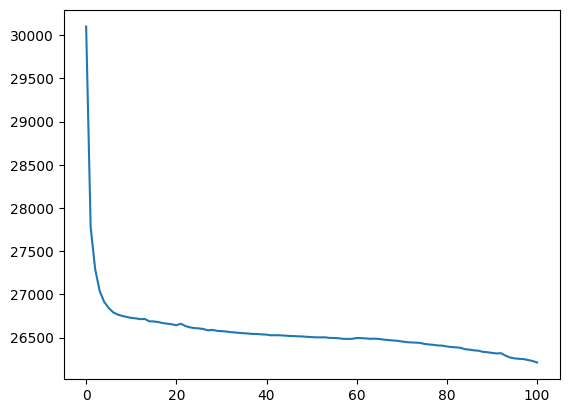

 MAPE (y > 0): 2.9807
[-0.0816578 -0.0816578  0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.   

/Users/basak/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/basak/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/basak/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/basak/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/basak/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [22]:
if best_weights is not None:
    model.load_state_dict(best_weights)
else:
    print("Best weights not found!")

print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history)
plt.show()

model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).numpy()
    y_true = y_test_tensor.numpy()
    long_indices = y_true[:, 0] > 1
    mape = mean_absolute_percentage_error(y_true[long_indices], y_pred[long_indices])
    print(" MAPE (y > 0): %.4f" % mape)
    # Test out inference with 5 samples
    for i in range(5):
        X_sample = X_test[i:i+1]  # numpy slicing
        X_sample = scaler.transform(X_sample)
        X_sample = torch.tensor(X_sample, dtype=torch.float32)
        y_pred = model(X_sample)
        print(f"{X_test.iloc[i].values} -> {y_pred[0].numpy()} (expected {y_test.iloc[i]})")


In [30]:
df=pd.read_parquet('21_06.parquet')
df['duration'] = df['duration'] / 60
Ys = df["duration"]
Xs = df[["usr", "nnumr", "cnumr", "elpl", "jobenv_req", "pri"]]
numerical_cols = ["nnumr", "cnumr"]  
categorical_cols = ["usr", "elpl", "jobenv_req", "pri"]  

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
    ('num', scaler, numerical_cols),
    ('cat', encoder, categorical_cols)
])

Xs_processed = preprocessor.fit_transform(Xs)
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + cat_feature_names.tolist()
Xs_processed_df = pd.DataFrame(Xs_processed, columns=all_feature_names)

X_train, X_test, y_train, y_test = train_test_split(Xs_processed_df, Ys, test_size=0.1, shuffle= True, random_state=42)

In [31]:
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
nonzero_indices = y_test != 0

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAPE:", mean_absolute_percentage_error(y_test[nonzero_indices], y_pred_rf[nonzero_indices]))

X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

gb = GradientBoostingRegressor(
    n_estimators=50,    
    learning_rate=0.2,   
    max_depth=7,        
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
nonzero_indices = y_test != 0


print("Gradient Boost Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("MSE:", mean_squared_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("MAPE:", mean_absolute_percentage_error(y_test[nonzero_indices], y_pred_gb[nonzero_indices]))


Random Forest Results
MAE: 96.08441181741334
MSE: 35746.9324871459
RMSE: 189.06859201661683
MAPE: 158.14069876761909
Gradient Boost Results:
MAE: 88.55958888602105
MSE: 33475.60607752697
RMSE: 182.96340092359173
MAPE: 154.99476334327835


In [32]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

scaler = StandardScaler()
scaler.fit(X_train_tensor.numpy())  

,copy,True
,with_mean,True
,with_std,True


In [33]:
model = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 214),  
    nn.ReLU(),
    nn.Linear(214, 116), 
    nn.ReLU(),              
    nn.Linear(116, 29),                
    nn.ReLU(),
    nn.Linear(29, 1)             
)

loss_fn = nn.MSELoss()  
optimizer = optim.Adam(model.parameters(), lr=0.00034165785088343217) 
n_epochs = 101  
batch_size = 32  
batch_start = torch.arange(0, len(X_train_tensor), batch_size)

best_mse = np.inf  
best_weights = None
history = []

In [34]:
for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train_tensor[start:start+batch_size]
            y_batch = y_train_tensor[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test_tensor)
    mse = loss_fn(y_pred, y_test_tensor)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())


if best_weights is not None:
    model.load_state_dict(best_weights)
else:
    print("Best weights not found!")

print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history)
plt.show()

model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).numpy()
    y_true = y_test_tensor.numpy()
    nonzero_indices = y_true[:, 0] != 0
    mape = mean_absolute_percentage_error(y_true[nonzero_indices], y_pred[nonzero_indices])
    print(" MAPE (y ≠ 0): %.4f" % mape)
    # Test out inference with 5 samples
    for i in range(5):
        X_sample = X_test[i:i+1]  # numpy slicing
        X_sample = scaler.transform(X_sample)
        X_sample = torch.tensor(X_sample, dtype=torch.float32)
        y_pred = model(X_sample)
        print(f"{X_test.iloc[i].values} -> {y_pred[0].numpy()} (expected {y_test.iloc[i]})")


KeyboardInterrupt: 